<a href="https://colab.research.google.com/github/sparshbansal-newton/deep-learning-labs/blob/main/Notebooks/8_Gradient_Descent_Types/Gradient_Descent_Types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 — Gradient Descent & Its Types
## Part 1: Batch vs. Stochastic Gradient Descent (PyTorch)

We train the **same** network three times on a small purchase-prediction dataset, changing only one thing — the **`batch_size`** — and watch how that single choice trades **training time** against how fast the **loss** falls.

**In this part you will see how to:**
- Tell Batch, and Stochastic GD apart by their number of weight updates per epoch.
- Write a small PyTorch training function (`fit`) whose update frequency is set by the `batch_size` you pass it.
- Compare regimes by reading the printed per-epoch loss and total time.

## 1. The Idea in Brief
Training repeatedly updates each weight by stepping *against* the gradient of the loss:

$$W_n = W_0 - \eta\,\frac{\partial L}{\partial w}$$

where $W_0$ is the current weight, $W_n$ the updated weight, $\eta$ the **learning rate** (`lr` in the code), and $\frac{\partial L}{\partial w}$ the gradient of the loss with respect to that weight. In the loop below, `loss.backward()` computes $\frac{\partial L}{\partial w}$ and `optimizer.step()` applies this formula.

The variants differ only in **how many samples feed each update**, which fixes the **number of updates per epoch**:

| Variant | Batch size $B$ | Updates / epoch |
|---|---|---|
| **Batch GD** | all $N$ | 1 |
| **Stochastic GD** | 1 | $N$ |

More updates per epoch → the loss falls faster per epoch, but more time is spent per epoch. That tension is the whole lab.

In [1]:
import numpy as np
import pandas as pd
import time
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

## 2. Data — Purchase Prediction
Predict `Purchased` (0/1) from `Age` and `EstimatedSalary`.

In [2]:
url = 'https://raw.githubusercontent.com/shivang98/Social-Network-ads-Boost/master/Social_Network_Ads.csv'
df = pd.read_csv(url)[['Age', 'EstimatedSalary', 'Purchased']]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


> **Pitfall — scale *after* splitting.** Fit the `StandardScaler` on the training rows only, then just transform the validation rows; fitting on everything leaks validation info into training.

In [3]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train
X_val   = scaler.transform(X_val)         # transform val only

> **Pitfall — label shape for `BCELoss`.** The loss compares outputs of shape `[N, 1]`. Leaving labels as a flat `[N]` vector makes PyTorch broadcast to `[N, N]` and compute nonsense — so reshape to a column with `.reshape(-1, 1)`.

In [4]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).reshape(-1, 1)

n_train = X_train_t.shape[0]   # number of training rows
print('training rows:', n_train)

training rows: 320


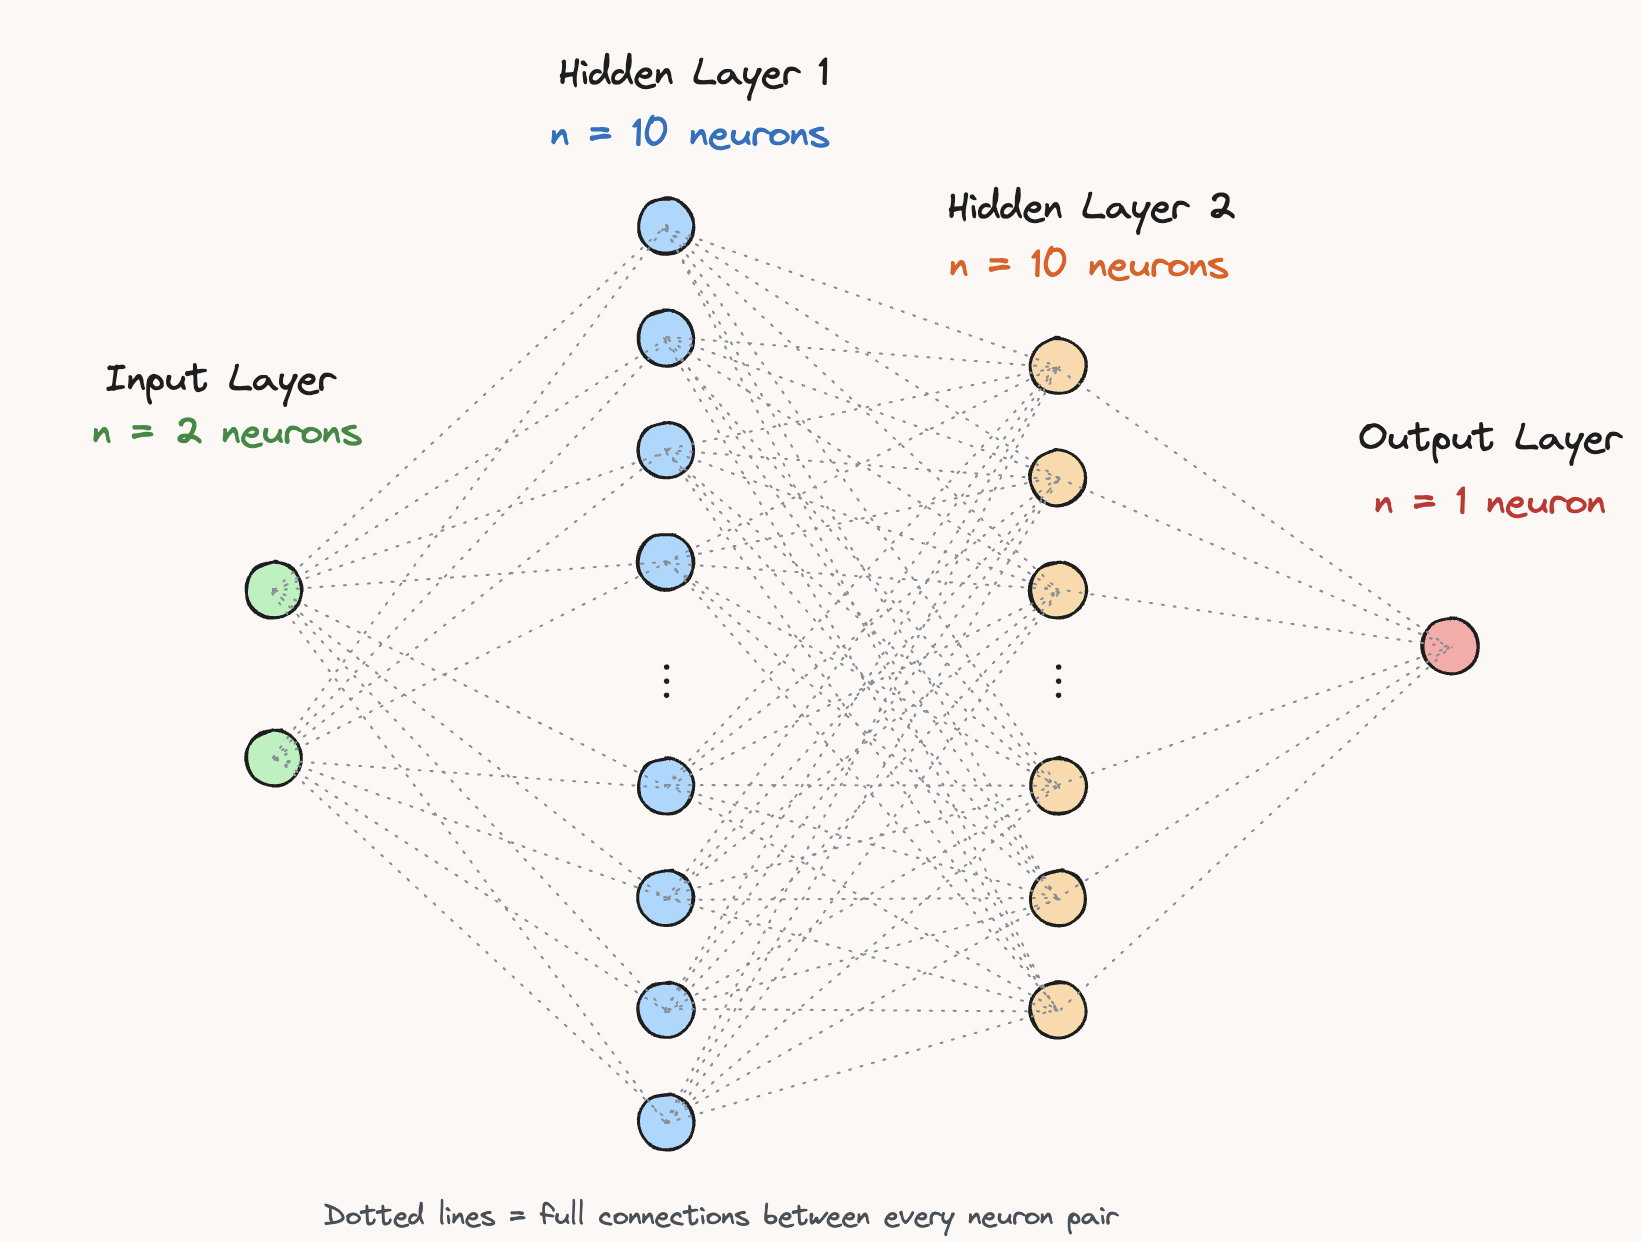

## 3. Model — Two Ways to Build the Same Network
A small network: 2 -> 10 -> 10 -> 1 with a sigmoid output. There are two common ways to define it in PyTorch, and they produce the **exact same architecture**:

- **Method 1 — subclass `nn.Module` (used in this lab).** Layers are created in `__init__`, and `forward()` spells out how data flows. Verbose, but flexible — you can add branches, skips, or debugging prints inside `forward()`.
- **Method 2 — `nn.Sequential` (compact shorthand).** Stacks layers in order with an implicit forward pass. Less code, but no room for custom logic between layers.

`build_model()` returns a fresh model each call so every run starts from the same random init (a fair comparison). We wire it to **Method 1**; Method 2 is shown right after for comparison.

In [5]:
# Method 1 — subclass nn.Module (this is what the lab trains with)
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(2, 10)
        self.layer2 = nn.Linear(10, 10)
        self.layer3 = nn.Linear(10, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.layer3(x)
        x = self.sigmoid(x)

        return x


def build_model():
    return MyModel()   # fresh weights each call -> fair comparison across runs

### Method 2 — `nn.Sequential` (compact equivalent)
The same 2 → 10 → 10 → 1 network in a fraction of the lines. Here the forward pass is implicit: layers simply run top-to-bottom in the order listed. This cell is just for comparison — the lab keeps training with Method 1 above.

In [6]:
# Method 2 — nn.Sequential: same architecture, shorter to write
model_sequential = nn.Sequential(
    nn.Linear(2, 10), nn.ReLU(),
    nn.Linear(10, 10), nn.ReLU(),
    nn.Linear(10, 1), nn.Sigmoid()
)
print(model_sequential)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
  (5): Sigmoid()
)


## 4. The Training Function
Keras' `model.fit()` hides the training loop. Here we write that loop ourselves in a small `fit()` — so you can see exactly what happens on every batch. The number of times the inner loop runs per epoch (= updates per epoch) is set purely by `batch_size`.

> **Pitfall — `optimizer.zero_grad()` first.** PyTorch *accumulates* gradients; without clearing them, each batch corrupts the next.

In [7]:
def fit(model, epochs, batch_size, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        perm = torch.randperm(n_train)                 # reshuffle the rows each epoch
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, n_train, batch_size):        # step through in batch_size chunks
            idx = perm[i:i + batch_size]               # indices of this batch
            xb, yb = X_train_t[idx], y_train_t[idx]    # slice out one batch by hand

            optimizer.zero_grad()             # 1. clear old gradients
            loss = criterion(model(xb), yb)   # 2+3. forward pass + loss L
            loss.backward()                   # 4. backprop -> computes dL/dw
            optimizer.step()                  # 5. update: W_n = W_0 - lr * dL/dw

            epoch_loss += loss.item()         # accumulate to report the epoch average
            n_batches += 1

        print(f'Epoch {epoch + 1:2d}/{epochs} - loss: {epoch_loss / n_batches:.4f}')

## 5. Run the Two Extremes
We demo the two ends of the spectrum — **Batch GD** and **Stochastic GD** — where the contrast is sharpest. (Mini-batch GD sits between them; you'll place it yourself in the quiz.) Same network, same everything — only `batch_size` changes, and **both runs use the same 10 epochs**. Holding epochs fixed lets us ask two separate questions: **(A)** which is faster in wall-clock time, and **(B)** for that same number of epochs, which converges faster? Watch **how fast the loss falls** and the **total time** in each output.

*(First, a one-time warm-up run so PyTorch's start-up cost doesn't unfairly land on the first timed run below — ignore its printed loss.)*

In [8]:
fit(build_model(), epochs=1, batch_size=32)   # warm-up only; ignore this output

Epoch  1/1 - loss: 0.6743


### Batch GD — `batch_size = all rows` → 1 update per epoch

In [9]:
model = build_model()
start = time.time()
fit(model, epochs=10, batch_size=n_train)     # whole training set in one batch
print('Total time:', round(time.time() - start, 2), 's')

Epoch  1/10 - loss: 0.7294
Epoch  2/10 - loss: 0.7174
Epoch  3/10 - loss: 0.7065
Epoch  4/10 - loss: 0.6963
Epoch  5/10 - loss: 0.6869
Epoch  6/10 - loss: 0.6782
Epoch  7/10 - loss: 0.6700
Epoch  8/10 - loss: 0.6623
Epoch  9/10 - loss: 0.6549
Epoch 10/10 - loss: 0.6478
Total time: 0.01 s


### Stochastic GD — `batch_size = 1` → one update per sample

In [10]:
model = build_model()
start = time.time()
fit(model, epochs=10, batch_size=1)
print('Total time:', round(time.time() - start, 2), 's')

Epoch  1/10 - loss: 0.4119
Epoch  2/10 - loss: 0.3091
Epoch  3/10 - loss: 0.2857
Epoch  4/10 - loss: 0.2662
Epoch  5/10 - loss: 0.2569
Epoch  6/10 - loss: 0.2675
Epoch  7/10 - loss: 0.2654
Epoch  8/10 - loss: 0.2573
Epoch  9/10 - loss: 0.2387
Epoch 10/10 - loss: 0.2422
Total time: 0.49 s


## 6. The Tradeoff
Both runs used the **same 10 epochs**, which lets us answer two separate questions:

- **Question A — Which is faster? (wall-clock time)**: Batch GD does 1 update per epoch → finishes quickest. Stochastic does one update per *sample* (hundreds per epoch) → clearly the slowest.
- **Question B — For the same number of epochs, which converges faster?**: the opposite order. Stochastic drops the loss sharply within the first epoch or two; Batch GD, with a single update per epoch, barely moves in 10 epochs.

| Regime | Total time | Loss drop per epoch | Verdict |
|---|:---:|:---:|---|
| **Batch GD** | ✅ fastest (1 update) | ❌ slow | stable but slow to converge |
| **Stochastic GD** | ❌ slowest ($N$ updates) | ✅ fast | fast to learn, expensive & noisy |

**Takeaway:** changing only `batch_size` moved both time and convergence — in *opposite* directions. "Faster" means different things for *seconds* vs *epochs*. **Mini-batch GD** (from your lecture) sits between these two extremes, capturing most of stochastic's fast convergence at a fraction of the cost — which is why it's the practical default. The quiz asks you to place it. In Part 2 you'll see how PyTorch's `DataLoader` automates the batching we did by hand here.

## 7. Quick Quiz
1. Stochastic GD was slowest in seconds yet dropped the loss fastest, and Batch GD the reverse. Explain both using *updates per epoch*.
2. **Mini-batch GD** (e.g. `batch_size=32`) was not run above. From its *updates per epoch*, where would its **total time** and **loss-drop speed** fall relative to the two extremes — and why is it the usual choice in practice?
3. A classmate says "SGD is always best because its loss fell fastest." Give one reason that's misleading.

## 8. Bonus (early finishers)
- Re-run all three with `lr=0.01` — does Batch GD fall even further behind?
- Add a `batch_size=8` run — where do its time and loss land relative to the others?
- Print `loss.item()` for the very first and last epoch of each run and tabulate the drop by hand.